[1.59919614e-01 3.74806381e+00 1.41466610e-01 2.08051516e-01
 6.09890190e-02 6.10485256e-02 6.11080843e-02 6.13851120e-07
 6.18358604e-07 4.75191796e-07]
mean= 5.953267761603029e-05
1 second= 419937436062.3128
line width= 0.25967192690727325


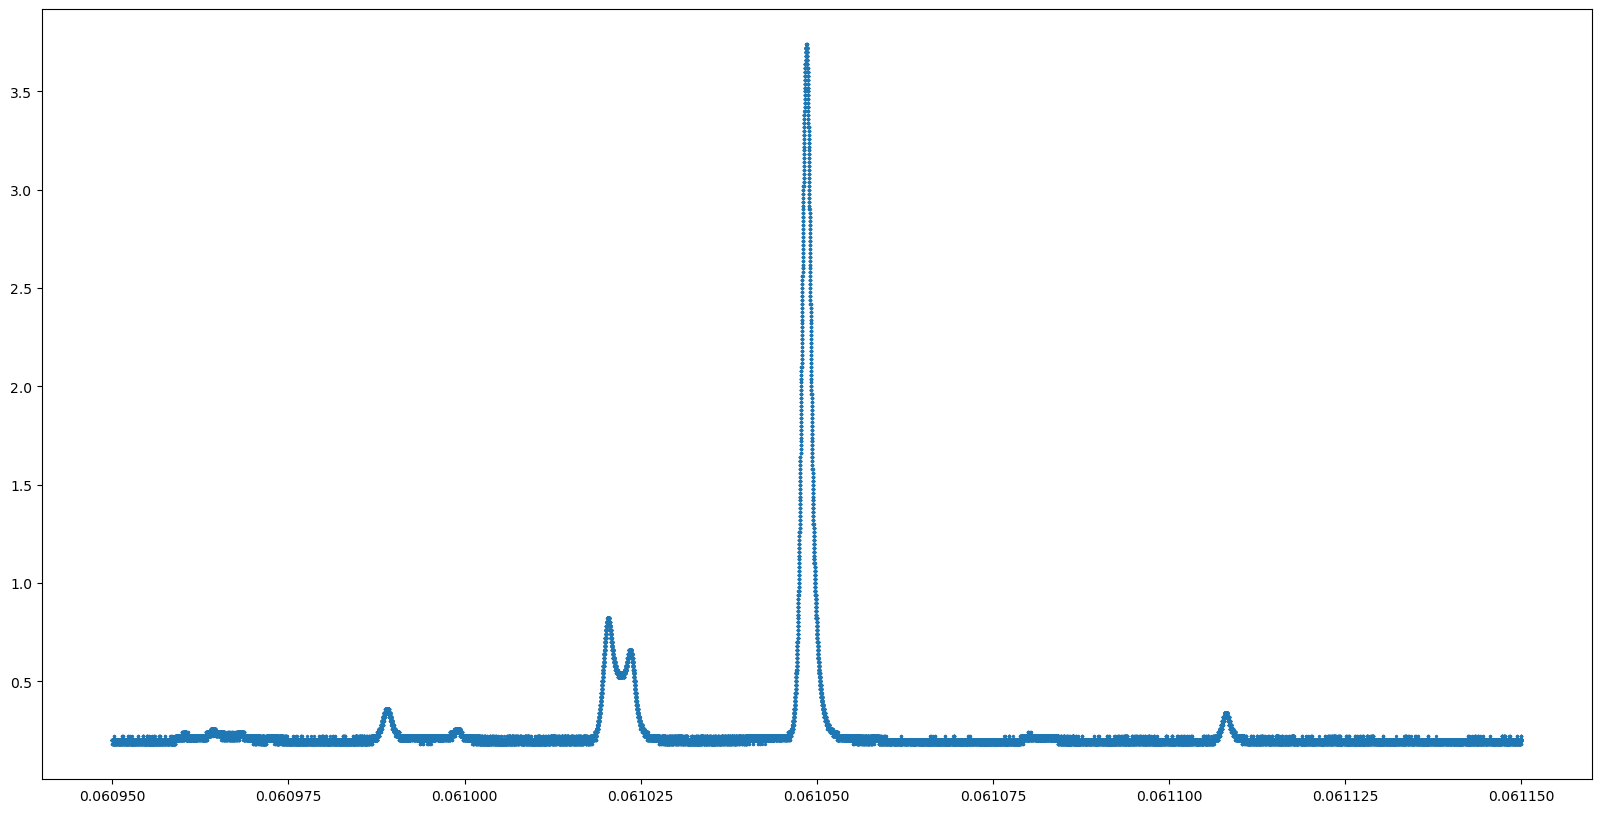

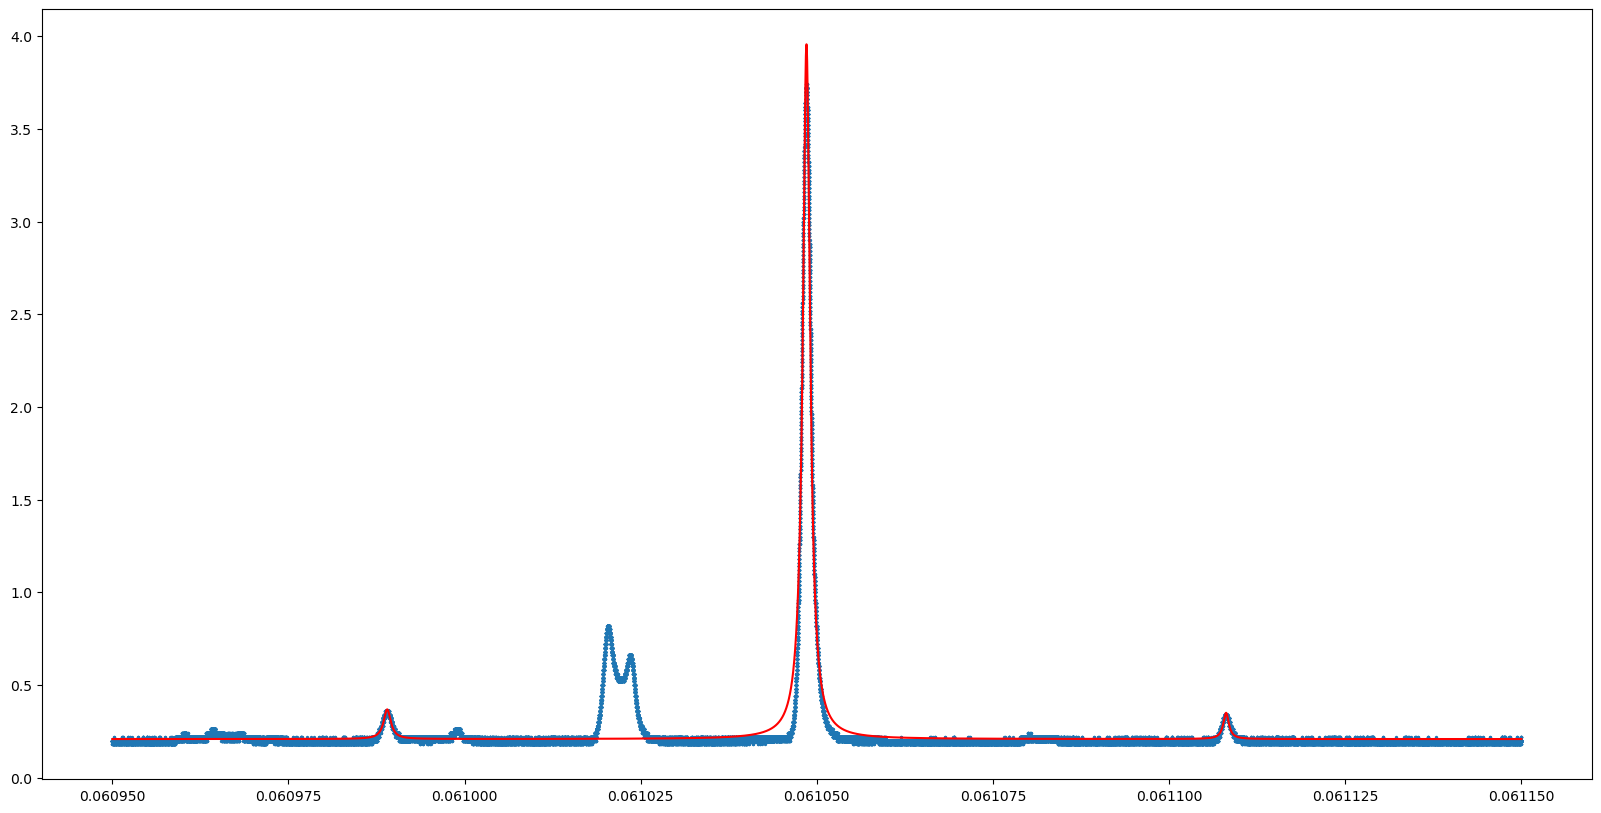

In [2]:
import pandas as pd   
import numpy as np
import matplotlib.pyplot as plt  
from scipy.optimize import curve_fit 


data = pd.read_csv(r"C:\Users\rsrut\OneDrive\Desktop\pythonapps\fp cavity data\TEK00003.CSV")

data1=data[(data['TIME']>0.06095) & (data['TIME']<0.06115)]

plt.figure(figsize=(20,10))
plt.scatter(data1['TIME'],data1['CH2'],s=2)


def lorentzian(x, A1, A2, A3,y1, x1, x2,x3, gamma1, gamma2,gamma3):
    return (y1 + A1 * gamma1**2 / ((x - x1)**2 + gamma1**2) + A2 * gamma2**2 / ((x - x2)**2 + gamma2**2)+A3 * gamma3**2 / ((x - x3)**2 + gamma3**2))


param, param_cov = curve_fit(lorentzian, data1['TIME'], data1['CH2'],p0=(0.21, 3.55, 0.21,0.18, 0.060989, 0.0610485,0.061108, 0.0000005,0.0000005,0.0000005))
A1, A2, A3,y1, x1, x2,x3, gamma1, gamma2,gamma3= param

print(param)

mean= ((x2-x1)+(x3-x2))/2
print("mean=", mean)

freq= (25*10**6)/mean
print("1 second=", freq)

line_width= freq*gamma2
print("line width=",line_width*10**(-6))



plt.figure(figsize=(20,10))
plt.scatter(data1['TIME'],data1['CH2'],s=2)
plt.plot(data1['TIME'],lorentzian(data1['TIME'],*param),'r')